In [1]:
import pandas as pd
import numpy as np

# =============================================================================
# DATA DIAGNOSTICS — NYC Childcare Optimization
#trying to learn more about the dataset

fac_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\child_care_regulated_nyc.csv")

cap_cols = ["infant_capacity", "toddler_capacity", "preschool_capacity",
            "school_age_capacity", "children_capacity", "total_capacity"]
fac_df[cap_cols] = fac_df[cap_cols].fillna(0)

# =============================================================================
# CHECK 1: Does children_capacity + school_age_capacity = total_capacity?

fac_df["reconstructed_total"] = fac_df["children_capacity"] + fac_df["school_age_capacity"]

# Only check rows where total_capacity > 0 (ignore empty rows)
mask = fac_df["total_capacity"] > 0
matches = (fac_df.loc[mask, "reconstructed_total"] == fac_df.loc[mask, "total_capacity"]).sum()
total_with_cap = mask.sum()
mismatches = total_with_cap - matches

print("=" * 60)
print("CHECK 1: children_capacity + school_age_capacity = total_capacity?")
print(f"  Rows with total_capacity > 0:   {total_with_cap}")
print(f"  Exact matches:                  {matches}")
print(f"  Mismatches:                     {mismatches}")
if mismatches > 0:
    print("\n  Sample mismatches:")
    bad = fac_df[mask & (fac_df["reconstructed_total"] != fac_df["total_capacity"])]
    print(bad[["facility_id", "children_capacity", "school_age_capacity",
               "reconstructed_total", "total_capacity"]].head(5).to_string(index=False))
print("=" * 60)

# =============================================================================
# CHECK 2: Does infant + toddler + preschool = children_capacity?
fac_df["known_0_5"] = (fac_df["infant_capacity"]
                       + fac_df["toddler_capacity"]
                       + fac_df["preschool_capacity"])

mask_has_breakdown = fac_df["known_0_5"] > 0
matches2 = (fac_df.loc[mask_has_breakdown, "known_0_5"]
            == fac_df.loc[mask_has_breakdown, "children_capacity"]).sum()
total_breakdown = mask_has_breakdown.sum()

print("\nCHECK 2: infant + toddler + preschool = children_capacity")
print(f"  (for facilities where breakdown exists)")
print(f"  Facilities with breakdown:      {total_breakdown}")
print(f"  Where sum = children_capacity:  {matches2}")
print(f"  Discrepancies:                  {total_breakdown - matches2}")
if total_breakdown - matches2 > 0:
    print("\n  Sample discrepancies:")
    bad2 = fac_df[mask_has_breakdown
                  & (fac_df["known_0_5"] != fac_df["children_capacity"])]
    print(bad2[["facility_id", "infant_capacity", "toddler_capacity",
                "preschool_capacity", "known_0_5", "children_capacity"]].head(5).to_string(index=False))
print("=" * 60)

# =============================================================================
# CHECK 3: n_f computation
# Use total_capacity when > 0.
# Fallback: children_capacity + school_age_capacity (NOT + infant/toddler/preschool)

fac_df["n_f"] = fac_df["total_capacity"]
mask_zero_total = fac_df["n_f"] == 0
fac_df.loc[mask_zero_total, "n_f"] = (
    fac_df.loc[mask_zero_total, "children_capacity"]
    + fac_df.loc[mask_zero_total, "school_age_capacity"]
)

print("\nCHECK 3: n_f computation")
print(f"  Used total_capacity directly:   {(~mask_zero_total).sum()}")
print(f"  Used fallback reconstruction:   {mask_zero_total.sum()}")
print(f"  Still zero after reconstruction:{(fac_df['n_f'] == 0).sum()}  (will be dropped)")
print("=" * 60)

# =============================================================================
# CHECK 4: n5_f — the three cases

def compute_n5(row):
    if row["known_0_5"] > 0:
        return row["known_0_5"]       # Case 1: use breakdown
    else:
        return row["children_capacity"]  # Case 2 or 3

fac_df["n5_f"] = fac_df.apply(compute_n5, axis=1)

case1 = (fac_df["known_0_5"] > 0).sum()
case2 = ((fac_df["known_0_5"] == 0) & (fac_df["children_capacity"] > 0)).sum()
case3 = ((fac_df["known_0_5"] == 0) & (fac_df["children_capacity"] == 0)).sum()

print("\nCHECK 4: n5_f case breakdown")
print(f"  Case 1 (breakdown available):   {case1}")
print(f"    → n5_f = infant+toddler+preschool")
print(f"  Case 2 (children_capacity only):{case2}")
print(f"    → n5_f = children_capacity (IS the 0-5 total)")
print(f"  Case 3 (no 0-5 data at all):    {case3}")
print(f"    → n5_f = 0")
print("=" * 60)

# =============================================================================
# CHECK 5: Active facility filter

print("\nCHECK 5: Facility status breakdown")
status_counts = fac_df["facility_status"].value_counts()
print(status_counts.to_string())
active = fac_df[fac_df["facility_status"].isin(["License", "Registration"])]
inactive = fac_df[~fac_df["facility_status"].isin(["License", "Registration"])]
print(f"\n  Active (License + Registration): {len(active)}")
print(f"  Excluded (other statuses):       {len(inactive)}")
print("=" * 60)

# =============================================================================
# CHECK 6: Missing lat/long

print("\nCHECK 6: Missing lat/long in active facilities")
active_missing_latlong = active["latitude"].isna().sum()
print(f"  Active facilities missing lat/long: {active_missing_latlong}")
print(f"  (Fine for Part 1 — zip code is all that's needed)")
print(f"  (Needed for Part 2 distance constraints)")
print("=" * 60)

# Check for duplicate facility IDs
dupes = fac_df["facility_id"].duplicated().sum()
print(f"  Duplicate facility IDs:          {dupes}")
fac_df = fac_df.drop_duplicates(subset=["facility_id"]).reset_index(drop=True)
print(f"  After deduplication:             {len(fac_df)}")



CHECK 1: children_capacity + school_age_capacity = total_capacity?
  Rows with total_capacity > 0:   7739
  Exact matches:                  7715
  Mismatches:                     24

  Sample mismatches:
 facility_id  children_capacity  school_age_capacity  reconstructed_total  total_capacity
      764811                  0                   20                   20              38
      226063                  0                  149                  149             170
      232906                  0                  177                  177             195
      838880                  0                   34                   34              49
      661155                  0                  420                  420             437

CHECK 2: infant + toddler + preschool = children_capacity
  (for facilities where breakdown exists)
  Facilities with breakdown:      24
  Where sum = children_capacity:  0
  Discrepancies:                  24

  Sample discrepancies:
 facility_id  infant

In [2]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# =============================================================================
# 1. LOAD DATA
# =============================================================================
# need 5 datasets to build the model:
#   - population_nyc:          how many kids (ages 0-5 and 6-12) live in each zip
#   - avg_individual_income:   median income per zip (used to flag high-need areas)
#   - employment_rate:         fraction of working-age adults employed per zip
#   - child_care_regulated:    every licensed/registered child-care facility in NYC
#                              with its current slot capacity by age group
#   - potential_locations:     candidate sites (lat/lon + zip) where brand-new
#                              facilities could be built

pop_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\population_nyc.csv")
inc_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\avg_individual_income_nyc.csv")
emp_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\employment_rate_nyc.csv")
fac_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\child_care_regulated_nyc.csv")
loc_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\potential_locations_nyc.csv")

# =============================================================================
# 2. CLEAN POPULATION DATA
# =============================================================================
# The raw CSV uses "-5" as the column name for the 0-5 age group and "Total"
# for all ages combined  so we rename these to something readable
# pop_0_12 is the combined child population (0-5 + 6-12) that the model is providing care slots for
# zipcodes becomes the master list we loop over everywhere below.

pop_df = pop_df.rename(columns={"Total": "pop_total", "-5": "pop_0_5"})
pop_df["pop_0_12"] = pop_df["pop_0_5"] + pop_df["6-12"]   # total kids 0-12
zipcodes = pop_df["zipcode"].tolist()                     

# =============================================================================
# 3. CLEAN INCOME & EMPLOYMENT DATA
# =============================================================================
# Rename columns so they match what we reference later in the merge.

inc_df = inc_df.rename(columns={"average income": "avg_income"})
emp_df = emp_df.rename(columns={"employment rate": "emp_rate"})  # stored as 0.0-1.0

# =============================================================================
# 4. CLEAN FACILITY DATA
# =============================================================================
# Drop any facility that isn't currently active which are closed or suspended facilities

active_statuses = ["License", "Registration"]
fac_df = fac_df[fac_df["facility_status"].isin(active_statuses)].copy()

# Some facilities have NaN in capacity fields (they didn't report a number)
# Replace with 0 so additions/comparisons don't mess up later
cap_cols = ["infant_capacity", "toddler_capacity", "preschool_capacity",
            "school_age_capacity", "children_capacity", "total_capacity"]
fac_df[cap_cols] = fac_df[cap_cols].fillna(0)

# known_0_5: the age-specific 0-5 count for facilities that reported a full
# breakdown (infants 0-1, toddlers 1-2, preschool 3-5).
fac_df["known_0_5"] = (
    fac_df["infant_capacity"]
    + fac_df["toddler_capacity"]
    + fac_df["preschool_capacity"]
)

# =============================================================================
# DATA STRUCTURE (confirmed by diagnostics):
#
# Case 1 (24 facilities):  breakdown exists, children_capacity = 0
#   -> age-specific columns are populated; use their sum as the 0-5 count
#   n5_f = infant + toddler + preschool
#
# Case 2 (6,201 facilities): no breakdown, children_capacity > 0
#   -> facility only reported one lump "children" bucket; treat it as 0-5
#   n5_f = children_capacity
#
# Case 3 (1,515 facilities): no 0-5 data at all
#   -> we have no info on how many infant/toddler slots exist; assume 0
#   n5_f = 0
#
# n_f = total_capacity in all cases (every facility reports this)
# =============================================================================

# n_f: total slots at the facility right now (used as the expansion baseline)
fac_df["n_f"] = fac_df["total_capacity"]

# compute_n5: picks the best available estimate of 0-5 slots per the cases above
def compute_n5(row):
    if row["known_0_5"] > 0:          # Case 1: we have a real age breakdown
        return row["known_0_5"]
    else:                              # Case 2 or 3: fall back to children_capacity (may be 0)
        return row["children_capacity"]

fac_df["n5_f"] = fac_df.apply(compute_n5, axis=1)

# Drop facilities with no zipcode (can't assign to any zone) and those with
# zero total capacity (they add nothing to supply)
fac_df = fac_df.dropna(subset=["zipcode"])
fac_df["zipcode"] = fac_df["zipcode"].astype(int)
fac_df = fac_df[fac_df["n_f"] > 0].reset_index(drop=True)

# Master list of facility IDs we'll use as variable indices in the model
facilities = fac_df["facility_id"].tolist()

print("=" * 55)
print("FACILITY DATA SUMMARY")
print(f"  Active facilities loaded:        {len(facilities)}")
print(f"  Case 1 - age breakdown exists:   {(fac_df['known_0_5'] > 0).sum()}")
print(f"  Case 2 - children_cap only:      {((fac_df['known_0_5']==0) & (fac_df['children_capacity']>0)).sum()}")
print(f"  Case 3 - no 0-5 data:            {((fac_df['known_0_5']==0) & (fac_df['children_capacity']==0)).sum()}")
print("=" * 55)

# =============================================================================
# 5. CLEAN LOCATION DATA
# =============================================================================
# Keep only the columns we need, deduplicate (some sites may appear twice in
# the raw file), and use the DataFrame row index as the location ID.

loc_df = loc_df[["zipcode", "latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
locations = loc_df.index.tolist()   # e.g. [0, 1, 2, ..., N-1]

# =============================================================================
# 6. ZIP PARAMETERS
# =============================================================================
# Merge the three zip-level tables into one lookup DataFrame,
# then compute two key demand thresholds per zip:
#   R_total: minimum total (all-age) slots required to eliminate a child-care desert
#   R_05:    minimum 0-5 slots required by NYC policy

zip_df = pop_df.merge(inc_df, on="zipcode", how="left")
zip_df = zip_df.merge(emp_df, on="zipcode", how="left")
zip_df = zip_df.fillna(0)   # zips with no income/employment data get 0

# H = 1 flags a zip as "high-need" if EITHER:
#   - average individual income is at or below $60,000 (low-income area), OR
#   - employment rate is at or above 60% (many working parents who need care)
# High-need zips require a higher coverage ratio (50% vs 33% of children)- this was in project description
zip_df["H"] = (
    (zip_df["avg_income"] <= 60000) | (zip_df["emp_rate"] >= 0.60)
).astype(int)

# R_total: the number of child-care slots (any age) the zip must have in total
#   High-need  (H=1): 50% of all children 0-12 must be covered
#   Normal     (H=0): 33% of all children 0-12 must be covered
zip_df["R_total"] = (
    0.5 * zip_df["H"] + (1/3) * (1 - zip_df["H"])
) * zip_df["pop_0_12"]

# R_05: NYC policy mandates that 2/3 of the 0-5 population must have a slot
zip_df["R_05"] = (2/3) * zip_df["pop_0_5"]

# Index by zipcode for fast lookup inside the optimization loops below
zip_params = zip_df.set_index("zipcode")

print("ZIP CODE DATA SUMMARY")
print(f"  Total zip codes:                 {len(zipcodes)}")
print(f"  High-demand zips:                {zip_df['H'].sum()}")
print(f"  Normal-demand zips:              {(zip_df['H']==0).sum()}")
print("=" * 55)

# =============================================================================
# 7. EXISTING FACILITY PARAMETERS
# =============================================================================
# Two cost/capacity parameters are computed for each existing facility:
#
# x_bar: the maximum number of ADDITIONAL slots we can add to this facility.
#   Capped at either 20% growth OR 500 total new slots  whichever is smaller.

# c_f: per-slot cost for the CHEAP expansion segment (Segment 1).
#   Based on a base rate of (20,000/n_f + 200) discounted to 90%:
#     c_f = 0.9 * (20,000/n_f + 200) = 18,000/n_f + 180

fac_df["x_bar"] = fac_df["n_f"].apply(lambda n: min(1.2 * n, 500))
fac_df["c_f"]   = fac_df["n_f"].apply(lambda n: (18000 / n) + 180)

# Index by facility_id for fast lookup inside the model-building loops
fac_params = fac_df.set_index("facility_id")

# =============================================================================
# 8. NEW FACILITY PARAMETERS
# =============================================================================
# Brand-new facilities come in three sizes. Key facts per size:
#   slots_s:    total child slots (all ages combined)
#   slots_05_s: slots reserved for 0-5 year-olds (exactly 50% of total)
#   FC_s:       fixed construction/setup cost (land, building, licensing)
#   C_new:      total cost = fixed cost + $100 per 0-5 slot (equipment)
#
# Resulting total costs:
#   small  = $65,000 + 100*50  = $70,000
#   medium = $95,000 + 100*100 = $105,000
#   large  = $115,000 + 100*200 = $135,000

sizes      = ["small", "medium", "large"]
slots_s    = {"small": 100,  "medium": 200,  "large": 400}
slots_05_s = {"small":  50,  "medium": 100,  "large": 200}
FC_s       = {"small": 65_000, "medium": 95_000, "large": 115_000}
C_new      = {s: FC_s[s] + 100 * slots_05_s[s] for s in sizes}
# small=$70,000 | medium=$105,000 | large=$135,000

# loc_params: same as loc_df but indexed by location integer ID
loc_params = loc_df.set_index(loc_df.index)

# Lookup dictionaries: given a zip code, which location indices / facility IDs belong to that zip? 
#These make the constraint loops below fast and readable.
zip_to_locs = {z: loc_df[loc_df["zipcode"] == z].index.tolist() for z in zipcodes}
zip_to_facs = {z: fac_df[fac_df["zipcode"] == z]["facility_id"].tolist() for z in zipcodes}

# =============================================================================
# 9. BUILD MODEL
# =============================================================================
# Create a Gurobi Mixed-Integer Program (MIP).
# MIPGap=0.01 means we accept a solution within 1% of proven optimal.
# TimeLimit=600 stops the solver after 10 minutes even if not fully optimal.

model = gp.Model("ChildCareDeserts_NYC_Part1")
model.setParam("MIPGap", 0.01)
model.setParam("TimeLimit", 600)

# =============================================================================
# 10. DECISION VARIABLES
#
# Each segment is further split by age group so we can track 0-5 coverage:
#   x1_05[f]  = 0-5 slots added in Segment 1 (cheap) at facility f
#   x1_612[f] = 6-12 slots added in Segment 1 (cheap) at facility f
#   x2_05[f]  = 0-5 slots added in Segment 2 (expensive) at facility f
#   x2_612[f] = 6-12 slots added in Segment 2 (expensive) at facility f
#
# b[f]: binary flag -- equals 1 if facility f has used up its entire cheap
#       segment and is now expanding into the expensive segment.
#
# y[l, s]: integer -- how many size-s new facilities to build at location l.
#          (Integer because you can't build 0.7 of a building.)
# =============================================================================

x1_05  = model.addVars(facilities, lb=0, name="x1_05")   # continuous >= 0
x1_612 = model.addVars(facilities, lb=0, name="x1_612")
x2_05  = model.addVars(facilities, lb=0, name="x2_05")
x2_612 = model.addVars(facilities, lb=0, name="x2_612")

b = model.addVars(facilities, vtype=GRB.BINARY, name="b")          # 0 or 1
y = model.addVars(locations, sizes, vtype=GRB.INTEGER, lb=0, name="y")  # 0,1,2,...

# =============================================================================
# 11. PIECEWISE EXPANSION CONSTRAINTS
# =============================================================================
# These four constraints per facility enforce the "fill cheap before expensive"
# piecewise cost logic using the binary variable b[f]:
#
#  (a) seg1_upper:  total cheap slots can't exceed n_f (the Segment 1 cap)
#  (b) seg1_lower:  if b=1 (expensive segment is active), the cheap segment
#                   MUST be completely filled first -- no skipping ahead
#  (c) seg2_limit:  expensive slots are only allowed when b=1, and are bounded
#                   by the remaining room up to x_bar
#  (d) total_limit: combined expansion (both segments) can never exceed x_bar
#
# Together (b) and (c) create a "Big-M" style coupling: b=0 forces x2=0,
# and b=1 forces x1 to its maximum, so the solver can't use the cheaper rate
# for more slots than n_f.

for f in facilities:
    nf   = fac_params.loc[f, "n_f"]
    xbar = fac_params.loc[f, "x_bar"]

    # (a) Segment 1 is capped at the current facility size
    model.addConstr(x1_05[f] + x1_612[f] <= nf,
                    name=f"seg1_upper_{f}")

    # (b) If b=1, segment 1 must be fully used (forces sequential fill)
    model.addConstr(x1_05[f] + x1_612[f] >= nf * b[f],
                    name=f"seg1_lower_{f}")

    # (c) Segment 2 is only unlocked when b=1, and is limited to the gap
    #     between the Segment 1 cap and the overall expansion ceiling
    model.addConstr(x2_05[f] + x2_612[f] <= (xbar - nf) * b[f],
                    name=f"seg2_limit_{f}")

    # (d) Hard ceiling on total slots added across both segments
    model.addConstr(x1_05[f] + x1_612[f] + x2_05[f] + x2_612[f] <= xbar,
                    name=f"total_limit_{f}")

# =============================================================================
# 12. COVERAGE CONSTRAINTS
# =============================================================================
# Two separate coverage requirements must be met for each zip code:
#
# (A) Total slots >= R_total  (eliminates the child-care desert overall)
#     Supply = existing capacity + expansion slots + new-build slots
#
# (B) 0-5 slots >= R_05  (NYC-specific infant/toddler policy target)
#     Supply = existing 0-5 capacity + 0-5 expansion slots + new-build 0-5 slots
#
# Zips where the threshold is 0 are skipped to keep the model compact.

# -(A) Total slot coverage ---
for z in zipcodes:
    R_tot = zip_params.loc[z, "R_total"]
    if R_tot <= 0:
        continue   # zip has no children, nothing to do

    # Fixed term: sum of current capacities of all facilities in this zip
    existing = sum(fac_params.loc[f, "n_f"] for f in zip_to_facs[z])

    # Variable term 1: expansion slots added to existing facilities in this zip
    expansion_expr = gp.quicksum(
        x1_05[f] + x1_612[f] + x2_05[f] + x2_612[f]
        for f in zip_to_facs[z]
    )

    # Variable term 2: slots contributed by any new facilities built in this zip
    new_expr = gp.quicksum(slots_s[s] * y[l, s]
                           for l in zip_to_locs[z] for s in sizes)

    # Constraint: total supply must reach the demand threshold
    model.addConstr(existing + expansion_expr + new_expr >= R_tot,
                    name=f"total_slots_{z}")

# (B) 0-5 slot coverage ---
for z in zipcodes:
    R_05 = zip_params.loc[z, "R_05"]
    if R_05 <= 0:
        continue   # no infants/toddlers in this zip, skip

    # Fixed term: current 0-5 capacity across all facilities in this zip
    existing_05 = sum(fac_params.loc[f, "n5_f"] for f in zip_to_facs[z])

    # Variable term 1: only the 0-5 portion of expansion (not 6-12)
    expansion_05_expr = gp.quicksum(x1_05[f] + x2_05[f] for f in zip_to_facs[z])

    # Variable term 2: 0-5 slots from new builds (50% of each new facility's total)
    new_05_expr = gp.quicksum(slots_05_s[s] * y[l, s]
                              for l in zip_to_locs[z] for s in sizes)

    # Constraint: 0-5 supply must hit the infant/toddler policy target
    model.addConstr(existing_05 + expansion_05_expr + new_05_expr >= R_05,
                    name=f"slots_05_{z}")

# =============================================================================
# 13. OBJECTIVE FUNCTION
# =============================================================================
# Minimise total cost = expansion cost + construction cost.
#
# Expansion cost for facility f:
#   Segment 1 (cheap):     c_f * (x1_05 + x1_612)          where c_f = 18000/n_f + 180
#   Segment 2 (expensive): (20000/n_f + 200) * (x2_05 + x2_612)
#   Equipment surcharge:   $100 per 0-5 slot added (applies to both segments)
#     -> 100 * (x1_05 + x2_05)
#
# Construction cost for new facilities:
#   C_new[s] * y[l, s]  (fixed cost already includes the equipment charge)
#
# The solver will naturally prefer cheap-segment expansions and smaller/fewer
# new builds, only escalating where the coverage constraints force it to.

expansion_cost = gp.quicksum(
    fac_params.loc[f, "c_f"] * (x1_05[f] + x1_612[f])                      # Segment 1 base cost
    + ((20000 / fac_params.loc[f, "n_f"]) + 200) * (x2_05[f] + x2_612[f])  # Segment 2 base cost
    + 100 * (x1_05[f] + x2_05[f])                                           # 0-5 equipment surcharge
    for f in facilities
)
construction_cost = gp.quicksum(C_new[s] * y[l, s]
                                 for l in locations for s in sizes)

model.setObjective(expansion_cost + construction_cost, GRB.MINIMIZE)

# =============================================================================
# 14. SOLVE
# =============================================================================
# Hand the model off to Gurobi's branch-and-bound MIP solver.
model.optimize()

# =============================================================================
# 15. OUTPUT
# =============================================================================
# Report results if Gurobi found at least one feasible solution.
# Status codes we accept:
#   GRB.OPTIMAL    (2)  = proven optimal within MIPGap
#   GRB.TIME_LIMIT (9)  = time ran out but a feasible solution was found
#   GRB.SUBOPTIMAL (13) = solution exists but optimality not confirmed

if model.Status in [GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.SUBOPTIMAL]:
    print("\n" + "=" * 55)
    print(f"  TOTAL MINIMUM FUNDING: ${model.ObjVal:,.0f}")
    print("=" * 55)

    # --- Existing facility expansions ---
    # Loop over every facility; print only those where the solver added slots.
    # Using > 0.5 instead of > 0 guards against tiny floating-point residuals
    # that Gurobi sometimes leaves on variables that should be exactly zero.
    print("\n--- Existing Facility Expansions ---")
    expanded = False
    for f in facilities:
        x1_05v  = x1_05[f].X    # .X retrieves the optimal variable value
        x1_612v = x1_612[f].X
        x2_05v  = x2_05[f].X
        x2_612v = x2_612[f].X
        xtot    = x1_05v + x1_612v + x2_05v + x2_612v

        if xtot > 0.5:   # effectively > 0 after accounting for floating point
            expanded = True
            nf   = fac_params.loc[f, "n_f"]
            z    = fac_params.loc[f, "zipcode"]
            # b[f].X > 0.5 means the binary "expensive segment" flag was set
            seg  = "Expensive" if b[f].X > 0.5 else "Cheap"
            # Recompute this facility's individual cost for the printout
            cost = (fac_params.loc[f, "c_f"] * (x1_05v + x1_612v)
                    + ((20000 / nf) + 200) * (x2_05v + x2_612v)
                    + 100 * (x1_05v + x2_05v))
            print(f"  Fac {f:>6} | Zip {z} | Existing: {nf:.0f} | "
                  f"Seg1: 0-5={round(x1_05v)} 6-12={round(x1_612v)} | "
                  f"Seg2: 0-5={round(x2_05v)} 6-12={round(x2_612v)} | "
                  f"Total added: {round(xtot)} ({100*xtot/nf:.1f}%) | "
                  f"Seg: {seg} | Cost: ${cost:,.0f}")
    if not expanded:
        print("  No expansions recommended.")

    # --- New facilities to build ---
    # y[l, s].X gives the number of size-s facilities the solver recommends
    # building at candidate location l. Only print non-zero entries.
    print("\n--- New Facilities to Build ---")
    built = False
    for l in locations:
        z = loc_params.loc[l, "zipcode"]
        for s in sizes:
            if y[l, s].X > 0.5:   # at least one facility of this size here
                built = True
                count = round(y[l, s].X)
                print(f"  Loc {l:>5} | Zip {z} | Size: {s:>6} | "
                      f"Count: {count} | "
                      f"Slots: {slots_s[s]*count} | "
                      f"0-5: {slots_05_s[s]*count} | "
                      f"Cost: ${C_new[s]*count:,.0f}")
    if not built:
        print("  No new facilities recommended.")

    # --- Zip code summary table ---
    # For each zip, compare pre-solve supply vs. post-solve supply against
    # both demand thresholds. Flags which zips were deserts before the solve
    # and shows any remaining gap (should be ~0 if the model is feasible).
    print("\n--- Zip Code Summary ---")
    print(f"{'Zip':<8} {'Demand':<8} {'Pop0-12':>8} "
          f"{'(C)Req':>8} {'(D)Have':>8} {'(E)Gap':>7} "
          f"{'(F)Req05':>9} {'(G)Have05':>10} {'(H)Gap05':>9} {'Desert?':>8}")
    print("-" * 95)

    total_gap    = 0   # running sum of unmet total-slot demand across all zips
    total_gap_05 = 0   # running sum of unmet 0-5 demand across all zips
    desert_count = 0   # number of zips that were deserts BEFORE the solve

    for z in zipcodes:
        R_tot    = zip_params.loc[z, "R_total"]
        R_05     = zip_params.loc[z, "R_05"]
        pop_0_12 = zip_params.loc[z, "pop_0_12"]
        H        = zip_params.loc[z, "H"]
        if R_tot <= 0 and R_05 <= 0:
            continue   # skip zips with no demand at all

        # Pre-solve supply: existing facilities only, no additions yet
        existing    = sum(fac_params.loc[f, "n_f"]  for f in zip_to_facs[z])
        existing_05 = sum(fac_params.loc[f, "n5_f"] for f in zip_to_facs[z])

        # Slots added by the solver at existing facilities in this zip
        added    = sum(x1_05[f].X + x1_612[f].X + x2_05[f].X + x2_612[f].X
                       for f in zip_to_facs[z])
        added_05 = sum(x1_05[f].X + x2_05[f].X for f in zip_to_facs[z])

        # Slots provided by new builds placed inside this zip
        new_slots = sum(slots_s[s]    * y[l,s].X for l in zip_to_locs[z] for s in sizes)
        new_05    = sum(slots_05_s[s] * y[l,s].X for l in zip_to_locs[z] for s in sizes)

        # Post-solve totals (what we have after all decisions are applied)
        have    = existing + added + new_slots
        have_05 = existing_05 + added_05 + new_05

        # Remaining gap (should be ~0 everywhere if the model solved feasibly)
        gap_tot = max(0, R_tot - have)
        gap_05  = max(0, R_05  - have_05)
        total_gap    += gap_tot
        total_gap_05 += gap_05

        # A zip was a "desert" if existing supply alone was below threshold
        was_desert = existing < R_tot
        if was_desert:
            desert_count += 1

        demand = "HIGH" if H else "NORMAL"
        print(f"  {z:<6} {demand:<8} {pop_0_12:>8.0f} "
              f"{R_tot:>8.0f} {have:>8.0f} {gap_tot:>7.0f} "
              f"{R_05:>9.0f} {have_05:>10.0f} {gap_05:>9.0f} "
              f"{'YES' if was_desert else 'no':>8}")

    print("-" * 95)
    print(f"\n  Original deserts:              {desert_count}")
    print(f"  Remaining gap after solve:     {total_gap:.0f} slots")       # should be 0
    print(f"  Remaining 0-5 gap after solve: {total_gap_05:.0f} slots")   # should be 0
    print(f"\n  Column guide:")
    print(f"  (C) = R_total threshold  |  (D) = total slots after solve")
    print(f"  (E) = gap = C - D        |  (F) = R_05 threshold")
    print(f"  (G) = 0-5 slots after solve  |  (H) = 0-5 gap = F - G")

else:
    # No feasible solution found -- likely means constraints can't all be met.
    # Check whether R_total or R_05 thresholds are too tight, or if candidate
    # locations are missing for some zip codes.
    print("Model infeasible or no solution found.")
    print(f"Status code: {model.Status}")

FACILITY DATA SUMMARY
  Active facilities loaded:        7712
  Case 1 - age breakdown exists:   24
  Case 2 - children_cap only:      6182
  Case 3 - no 0-5 data:            1506
ZIP CODE DATA SUMMARY
  Total zip codes:                 211
  High-demand zips:                128
  Normal-demand zips:              83
Set parameter Username
Set parameter LicenseID to value 2773992
Academic license - for non-commercial use only - expires 2027-02-02
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 600
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.01

Optimize a model with 31207 rows, 131860 columns and 246491 nonzeros (Min)
Model fingerprint: 0x88481fa0
Model has 124148 linear objective coefficients
Variable types: 30848 continuous, 

In [3]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
from math import radians, cos

# =============================================================================
# 1. LOAD DATA
# =============================================================================
# Same five source files as Part 1.
# The key NEW requirement in Part 2 is that facilities must have latitude/longitude
# coordinates so we can enforce minimum-distance rules between locations.

pop_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\population_nyc.csv")
inc_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\avg_individual_income_nyc.csv")
emp_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\employment_rate_nyc.csv")
fac_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\child_care_regulated_nyc.csv")
loc_df = pd.read_csv(r"C:\Users\annal\OneDrive\Desktop\potential_locations_nyc.csv")

# =============================================================================
# 2. CLEAN POPULATION DATA
# =============================================================================
# Same as Part 1: rename columns, create combined 0-12 child population,
# and build the master zip code list

pop_df = pop_df.rename(columns={"Total": "pop_total", "-5": "pop_0_5"})
pop_df["pop_0_12"] = pop_df["pop_0_5"] + pop_df["6-12"]
zipcodes = pop_df["zipcode"].tolist()

# =============================================================================
# 3. CLEAN INCOME & EMPLOYMENT DATA
# =============================================================================

inc_df = inc_df.rename(columns={"average income": "avg_income"})
emp_df = emp_df.rename(columns={"employment rate": "emp_rate"})  # stored as 0.0-1.0

# =============================================================================
# 4. CLEAN FACILITY DATA
# =============================================================================
# Same active-status filter and capacity logic as Part 1
# ADDED in Part 2: after all the standard cleaning, drop any facility that is
# missing lat/lon coordinates because we need those to compute distances.

active_statuses = ["License", "Registration"]
fac_df = fac_df[fac_df["facility_status"].isin(active_statuses)].copy()

cap_cols = ["infant_capacity", "toddler_capacity", "preschool_capacity",
            "school_age_capacity", "children_capacity", "total_capacity"]
fac_df[cap_cols] = fac_df[cap_cols].fillna(0)

fac_df["known_0_5"] = (
    fac_df["infant_capacity"]
    + fac_df["toddler_capacity"]
    + fac_df["preschool_capacity"]
)

# =============================================================================
# DATA STRUCTURE (same three cases as Part 1):
#
# Case 1 (24 facilities):  age breakdown exists -> n5_f = infant+toddler+preschool
# Case 2 (6,201):          children_capacity only -> n5_f = children_capacity
# Case 3 (1,515):          no 0-5 data at all -> n5_f = 0
# n_f = total_capacity in all cases
# =============================================================================

fac_df["n_f"] = fac_df["total_capacity"]

def compute_n5(row):
    if row["known_0_5"] > 0:
        return row["known_0_5"]
    else:
        return row["children_capacity"]

fac_df["n5_f"] = fac_df.apply(compute_n5, axis=1)

fac_df = fac_df.dropna(subset=["zipcode"])
fac_df["zipcode"] = fac_df["zipcode"].astype(int)
fac_df = fac_df[fac_df["n_f"] > 0]

# Part 2 specific: drop facilities with missing coordinates
# We track how many were removed so it shows up in the summary printout
fac_before = len(fac_df)
fac_df = fac_df.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
fac_after  = len(fac_df)

facilities = fac_df["facility_id"].tolist()

print("=" * 55)
print("FACILITY DATA SUMMARY")
print(f"  Active facilities loaded:        {fac_after}")
print(f"  Dropped (missing lat/long):      {fac_before - fac_after}")
print(f"  Case 1 - age breakdown exists:   {(fac_df['known_0_5'] > 0).sum()}")
print(f"  Case 2 - children_cap only:      {((fac_df['known_0_5']==0) & (fac_df['children_capacity']>0)).sum()}")
print(f"  Case 3 - no 0-5 data:            {((fac_df['known_0_5']==0) & (fac_df['children_capacity']==0)).sum()}")
print("=" * 55)

# =============================================================================
# 5. CLEAN LOCATION DATA
# =============================================================================
# Same deduplication as Part 1, but also drop rows missing lat/lon because (they can't participate in distance filtering).

loc_df = loc_df[["zipcode", "latitude", "longitude"]].dropna().drop_duplicates().reset_index(drop=True)

# =============================================================================
# 6. VECTORIZED HAVERSINE DISTANCE (miles)
# =============================================================================
# Haversine gives the great-circle distance between two points on Earth.
# We use miles (R = 3958.8 miles).
#
# The function takes one "source" point (lat1, lon1) and an ARRAY of target
# points (lat2_arr, lon2_arr), returning a numpy array of distances.
# This vectorized form is much faster than calling the formula in a Python loop
# and this is critical because we need to check every location against every facility.
#
# MIN_DIST = 0.06 miles (~320 feet / ~100 meters): two facilities closer than
# this are considered "too close" — building another one there would be redundant
# and would create competition rather than expanding coverage

MIN_DIST = 0.06  # miles

def haversine_vectorized(lat1, lon1, lat2_arr, lon2_arr):
    R = 3958.8                        # Earth's radius in miles
    lat1r = radians(lat1)             # convert source point to radians
    lon1r = radians(lon1)
    lat2r = np.radians(lat2_arr)      # convert all target points at once
    lon2r = np.radians(lon2_arr)
    dlat  = lat2r - lat1r             # latitude difference
    dlon  = lon2r - lon1r             # longitude difference
    # Haversine formula: a = sin^2(dlat/2) + cos(lat1)*cos(lat2)*sin^2(dlon/2)
    a = np.sin(dlat/2)**2 + cos(lat1r) * np.cos(lat2r) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# =============================================================================
# 7. PREPROCESSING — REMOVE LOCATIONS TOO CLOSE TO EXISTING FACILITIES
# =============================================================================
# Before building the model, we throw out any candidate location whose nearest
# existing facility is less than MIN_DIST away.
# Reason: building a new facility right next to an existing one wastes money
# (it adds slots to an area that already has coverage) — preemptively removing
# these keeps the model smaller and the solutions more sensible.
#
# Algorithm:
#   For each candidate location l, compute its distance to ALL existing facilities.
#   If the minimum of those distances < MIN_DIST, mark l for removal.

print("Preprocessing: removing locations too close to existing facilities...")

fac_lats = fac_df["latitude"].values    # numpy arrays for fast vectorized math
fac_lons = fac_df["longitude"].values
loc_lats  = loc_df["latitude"].values
loc_lons  = loc_df["longitude"].values

keep_mask = np.ones(len(loc_df), dtype=bool)   # start by keeping everything
for i in range(len(loc_df)):
    # Compute distances from candidate location i to every existing facility
    dists = haversine_vectorized(loc_lats[i], loc_lons[i], fac_lats, fac_lons)
    if dists.min() < MIN_DIST:
        keep_mask[i] = False   # this candidate site is too close to an existing facility

loc_before = len(loc_df)
loc_df     = loc_df[keep_mask].reset_index(drop=True)
loc_after  = len(loc_df)
locations  = loc_df.index.tolist()

print(f"  Locations before filtering:      {loc_before}")
print(f"  Locations removed (too close):   {loc_before - loc_after}")
print(f"  Locations remaining:             {loc_after}")
print("=" * 55)

# =============================================================================
# 8. BUILD CLOSE PAIRS AMONG NEW LOCATIONS (per zip)
# =============================================================================
# Even after removing candidates that are too close to EXISTING facilities,
# some candidate sites may be very close to EACH OTHER.
# We can't build two new facilities within MIN_DIST of each other either.
# Here we precompute which pairs qualify by checking all pairs WITHIN each zip
# (sites in different zips are typically far apart, so we skip cross-zip checks).
# close_pairs stores (l, lp) tuples where l and lp are location indices.

print("Building close pairs among new locations...")

# Build the zip -> location and zip -> facility lookup dicts now that loc_df is final
zip_to_locs = {z: loc_df[loc_df["zipcode"] == z].index.tolist() for z in zipcodes}
zip_to_facs = {z: fac_df[fac_df["zipcode"] == z]["facility_id"].tolist() for z in zipcodes}

loc_lats = loc_df["latitude"].values
loc_lons = loc_df["longitude"].values

close_pairs = []
for z in zipcodes:
    locs_z = zip_to_locs[z]
    if len(locs_z) < 2:
        continue   # need at least 2 sites in a zip to form a pair
    for i in range(len(locs_z)):
        l         = locs_z[i]
        remaining = locs_z[i+1:]   # only check pairs we haven't seen yet (avoid duplicates)
        if not remaining:
            continue
        # Compute distances from location l to all remaining locations in this zip
        dists = haversine_vectorized(
            loc_lats[l], loc_lons[l],
            loc_lats[remaining], loc_lons[remaining]
        )
        for lp, d in zip(remaining, dists):
            if d < MIN_DIST:
                close_pairs.append((l, lp))   # this pair needs a "pick at most one" constraint

print(f"  Close new-new pairs found:       {len(close_pairs)}")
print("=" * 55)

# =============================================================================
# 9. ZIP PARAMETERS
# =============================================================================
# Identical to Part 1: merge income and employment onto population,
# flag high-need zips (H=1), compute R_total and R_05 thresholds.

zip_df = pop_df.merge(inc_df, on="zipcode", how="left")
zip_df = zip_df.merge(emp_df, on="zipcode", how="left")
zip_df = zip_df.fillna(0)

# H = 1 if income <= $60K OR employment rate >= 60%
zip_df["H"] = (
    (zip_df["avg_income"] <= 60000) | (zip_df["emp_rate"] >= 0.60)
).astype(int)

# R_total: 50% of 0-12 pop (high-need) or 33% (normal)
zip_df["R_total"] = (
    0.5 * zip_df["H"] + (1/3) * (1 - zip_df["H"])
) * zip_df["pop_0_12"]

# R_05: NYC policy requires 2/3 of 0-5 population to have a slot
zip_df["R_05"] = (2/3) * zip_df["pop_0_5"]

zip_params = zip_df.set_index("zipcode")

print("ZIP CODE DATA SUMMARY")
print(f"  Total zip codes:                 {len(zipcodes)}")
print(f"  High-demand zips:                {zip_df['H'].sum()}")
print(f"  Normal-demand zips:              {(zip_df['H']==0).sum()}")
print("=" * 55)

# =============================================================================
# 10. EXISTING FACILITY PARAMETERS
# =============================================================================
# Part 2 introduces a THREE-SEGMENT piecewise cost structure (vs. two in Part 1).
# The total expansion cap is strictly 20% of current size (no 500-slot hard cap).
#
# The 20% is divided into three incremental bands, each with a rising per-slot cost
# reflecting that further expansion requires more expensive modifications:
#
#   Segment 1: 0-10% expansion   cost = (20000 + 200*n_f) / n_f   = 200/n_f*1000 + 200
#   Segment 2: 10-15% expansion  cost = (20000 + 400*n_f) / n_f   (more expensive)
#   Segment 3: 15-20% expansion  cost = (20000 + 1000*n_f) / n_f  (most expensive)
#
# Each segment's incremental capacity:
#   Seg 1: 10% of n_f slots
#   Seg 2:  5% of n_f slots  (15% - 10%)
#   Seg 3:  5% of n_f slots  (20% - 15%)

fac_df["x_bar"]     = fac_df["n_f"] * 0.2   # hard cap: max 20% growth
fac_df["cost_seg1"] = fac_df["n_f"].apply(lambda n: (20000 +  200 * n) / n)
fac_df["cost_seg2"] = fac_df["n_f"].apply(lambda n: (20000 +  400 * n) / n)
fac_df["cost_seg3"] = fac_df["n_f"].apply(lambda n: (20000 + 1000 * n) / n)

fac_params = fac_df.set_index("facility_id")

# =============================================================================
# 11. NEW FACILITY PARAMETERS
# =============================================================================
# Same three sizes and costs as Part 1:
#   small:  100 total slots, 50 are 0-5, total cost $70,000
#   medium: 200 total slots, 100 are 0-5, total cost $105,000
#   large:  400 total slots, 200 are 0-5, total cost $135,000
# C_new = fixed construction cost + $100 per 0-5 slot (equipment)

sizes      = ["small", "medium", "large"]
slots_s    = {"small": 100,  "medium": 200,  "large": 400}
slots_05_s = {"small":  50,  "medium": 100,  "large": 200}
FC_s       = {"small": 65_000, "medium": 95_000, "large": 115_000}
C_new      = {s: FC_s[s] + 100 * slots_05_s[s] for s in sizes}
# small=$70,000 | medium=$105,000 | large=$135,000

loc_params = loc_df.copy()   # used in output section to look up zip by location index

# =============================================================================
# 12. BUILD MODEL
# =============================================================================
# Same solver settings as Part 1: accept within 1% of optimal, stop after 10 min.

model = gp.Model("ChildCareDeserts_NYC_Part2")
model.setParam("MIPGap", 0.01)
model.setParam("TimeLimit", 600)

# =============================================================================
# 13. DECISION VARIABLES
#
# Part 2 has THREE expansion segments per facility instead of two.
# Each segment is split by age group (0-5 and 6-12) as before:
#
#   x1_05[f],  x1_612[f]  -- slots added in segment 1 (0-10% band)
#   x2_05[f],  x2_612[f]  -- slots added in segment 2 (10-15% band)
#   x3_05[f],  x3_612[f]  -- slots added in segment 3 (15-20% band)
#
# Binary segment flags (one per segment per facility):
#   b1[f] = 1 if ANY expansion into segment 1 occurred
#   b2[f] = 1 if segment 2 was opened (requires b1=1 and seg1 fully used)
#   b3[f] = 1 if segment 3 was opened (requires b2=1 and seg2 fully used)
#   The ordering constraint b1 >= b2 >= b3 enforces sequential fill.
#
# y[l, s]: BINARY (not integer like Part 1) -- at most ONE facility per location.
#   The distance constraints and one-size constraints together mean you can't
#   stack multiple buildings at the same spot, so binary is the right type here.
# =============================================================================

x1_05  = model.addVars(facilities, lb=0, name="x1_05")
x1_612 = model.addVars(facilities, lb=0, name="x1_612")
x2_05  = model.addVars(facilities, lb=0, name="x2_05")
x2_612 = model.addVars(facilities, lb=0, name="x2_612")
x3_05  = model.addVars(facilities, lb=0, name="x3_05")
x3_612 = model.addVars(facilities, lb=0, name="x3_612")

b1 = model.addVars(facilities, vtype=GRB.BINARY, name="b1")  # seg1 active flag
b2 = model.addVars(facilities, vtype=GRB.BINARY, name="b2")  # seg2 active flag
b3 = model.addVars(facilities, vtype=GRB.BINARY, name="b3")  # seg3 active flag

# y is BINARY: 0 or 1 per (location, size) — at most one facility per location
y = model.addVars(locations, sizes, vtype=GRB.BINARY, name="y")

# =============================================================================
# 14. EXPANSION CONSTRAINTS (CUMULATIVE THREE-SEGMENT)
# =============================================================================
# For each facility we add 7 constraints that together enforce:
#   (a) Segments must be activated in order: b1 >= b2 >= b3
#       (can't open seg2 without first having opened seg1, etc.)
#   (b) Each segment's slots are bounded above by that segment's incremental cap
#       multiplied by its binary flag (so the cap applies only when active)
#   (c) If the NEXT segment is active (its binary = 1), the CURRENT segment must
#       be completely filled — this is the "fill before escalating" rule
#
# Segment capacities (as fractions of n_f):
#   Seg 1 cap: 10% of n_f
#   Seg 2 cap:  5% of n_f
#   Seg 3 cap:  5% of n_f
#   Total:     20% of n_f = x_bar

for f in facilities:
    nf = fac_params.loc[f, "n_f"]

    # (a) Ordering: seg1 must be active before seg2, seg2 before seg3
    model.addConstr(b1[f] >= b2[f], name=f"nest_12_{f}")
    model.addConstr(b2[f] >= b3[f], name=f"nest_23_{f}")

    # --- Segment 1 (0-10% of n_f) ---
    seg1_cap = 0.10 * nf
    # Upper bound: can't add more than seg1_cap slots in this segment
    model.addConstr(x1_05[f] + x1_612[f] <= seg1_cap * b1[f], name=f"seg1_upper_{f}")
    # Force-fill: if seg2 is open (b2=1), seg1 must be at its cap
    model.addConstr(x1_05[f] + x1_612[f] >= seg1_cap * b2[f], name=f"seg1_full_if_seg2_{f}")

    # --- Segment 2 (10-15% of n_f, incremental 5%) ---
    seg2_cap = 0.05 * nf
    # Upper bound: can't exceed incremental seg2 capacity
    model.addConstr(x2_05[f] + x2_612[f] <= seg2_cap * b2[f], name=f"seg2_upper_{f}")
    # Force-fill: if seg3 is open (b3=1), seg2 must be at its cap
    model.addConstr(x2_05[f] + x2_612[f] >= seg2_cap * b3[f], name=f"seg2_full_if_seg3_{f}")

    # --- Segment 3 (15-20% of n_f, incremental 5%) ---
    seg3_cap = 0.05 * nf
    # Upper bound only — no "force-fill" needed since no segment 4 exists
    model.addConstr(x3_05[f] + x3_612[f] <= seg3_cap * b3[f], name=f"seg3_upper_{f}")

# =============================================================================
# 15. COVERAGE CONSTRAINTS
# =============================================================================
# Same structure as Part 1, but the expansion expression now includes
# all THREE segments (x1 + x2 + x3) instead of two

# --- Total slot coverage (desert elimination) ---
for z in zipcodes:
    R_tot = zip_params.loc[z, "R_total"]
    if R_tot <= 0:
        continue

    existing = sum(fac_params.loc[f, "n_f"] for f in zip_to_facs[z])

    # All three expansion segments contribute to total supply
    expansion_expr = gp.quicksum(
        x1_05[f] + x1_612[f] + x2_05[f] + x2_612[f] + x3_05[f] + x3_612[f]
        for f in zip_to_facs[z]
    )
    new_expr = gp.quicksum(slots_s[s] * y[l, s]
                           for l in zip_to_locs[z] for s in sizes)

    model.addConstr(existing + expansion_expr + new_expr >= R_tot,
                    name=f"total_slots_{z}")

# --- 0-5 slot coverage (NYC infant/toddler policy) ---
for z in zipcodes:
    R_05 = zip_params.loc[z, "R_05"]
    if R_05 <= 0:
        continue

    existing_05 = sum(fac_params.loc[f, "n5_f"] for f in zip_to_facs[z])

    # Only the _05 variables across all three segments count toward infant coverage
    expansion_05_expr = gp.quicksum(
        x1_05[f] + x2_05[f] + x3_05[f]
        for f in zip_to_facs[z]
    )
    new_05_expr = gp.quicksum(slots_05_s[s] * y[l, s]
                              for l in zip_to_locs[z] for s in sizes)

    model.addConstr(existing_05 + expansion_05_expr + new_05_expr >= R_05,
                    name=f"slots_05_{z}")

# =============================================================================
# 16. DISTANCE CONSTRAINTS (new-new pairs only)
# =============================================================================
# For every pair of candidate sites that are within MIN_DIST of each other,
# add a constraint: sum of facilities built across BOTH sites <= 1.
# This means at most one of the two can be selected regardless of size

for (l, lp) in close_pairs:
    model.addConstr(
        gp.quicksum(y[l,  s] for s in sizes) +   # total facilities at site l
        gp.quicksum(y[lp, s] for s in sizes) <= 1,  # total facilities at site lp
        name=f"dist_{l}_{lp}"
    )

# =============================================================================
# 16b. AT MOST ONE SIZE PER LOCATION
# =============================================================================
# A single candidate site can only host one facility of one size.
# This prevents the model from building, say, a small AND a large facility
# at the same address (which would be physically impossible).
# Combined with the binary y variables, this means each site is either
# unused (all y=0) or has exactly one facility of one size (one y=1).

for l in locations:
    model.addConstr(
        gp.quicksum(y[l, s] for s in sizes) <= 1,
        name=f"one_size_{l}"
    )

# =============================================================================
# 17. OBJECTIVE FUNCTION
# =============================================================================
# Minimise total cost = expansion cost + construction cost.
#
# Expansion cost for facility f (three segments):
#   Seg 1: cost_seg1[f] * (x1_05[f] + x1_612[f])
#   Seg 2: cost_seg2[f] * (x2_05[f] + x2_612[f])
#   Seg 3: cost_seg3[f] * (x3_05[f] + x3_612[f])
#   Equipment surcharge: $100 per 0-5 slot added in ANY segment
#     -> 100 * (x1_05 + x2_05 + x3_05)
#
# Construction cost: C_new[s] * y[l, s]  (already includes equipment cost)
#
# Because cost_seg1 < cost_seg2 < cost_seg3, the solver naturally fills
# cheaper segments first — matching the intent of the piecewise structure.

expansion_cost = gp.quicksum(
    fac_params.loc[f, "cost_seg1"] * (x1_05[f] + x1_612[f])   # Segment 1 base cost
    + fac_params.loc[f, "cost_seg2"] * (x2_05[f] + x2_612[f]) # Segment 2 base cost
    + fac_params.loc[f, "cost_seg3"] * (x3_05[f] + x3_612[f]) # Segment 3 base cost
    + 100 * (x1_05[f] + x2_05[f] + x3_05[f])                  # 0-5 equipment surcharge
    for f in facilities
)
construction_cost = gp.quicksum(
    C_new[s] * y[l, s] for l in locations for s in sizes
)
model.setObjective(expansion_cost + construction_cost, GRB.MINIMIZE)

# =============================================================================
# 18. SOLVE
# =============================================================================
# Hand the model to Gurobi's branch-and-bound MIP solver.
# With three binary variables per facility plus binary y, this is a larger
# MIP than Part 1 — the 10-minute time limit may be more likely to bind.

model.optimize()

# =============================================================================
# 19. OUTPUT
# =============================================================================
# Same reporting structure as Part 1, extended for three segments.

if model.Status in [GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.SUBOPTIMAL]:
    print("\n" + "=" * 55)
    print(f"  TOTAL MINIMUM FUNDING: ${model.ObjVal:,.0f}")
    print("=" * 55)

    # --- Existing facility expansions ---
    # xtot > 0.5 guards against floating-point residuals (same logic as Part 1).
    # The "active seg" printout shows the HIGHEST segment reached:
    #   b1=1 but b2=0 -> only segment 1 was used
    #   b2=1 but b3=0 -> segments 1+2 were used
    #   b3=1           -> all three segments were used
    print("\n--- Existing Facility Expansions ---")
    expanded = False
    for f in facilities:
        x1_05v  = x1_05[f].X;  x1_612v = x1_612[f].X
        x2_05v  = x2_05[f].X;  x2_612v = x2_612[f].X
        x3_05v  = x3_05[f].X;  x3_612v = x3_612[f].X
        xtot = x1_05v + x1_612v + x2_05v + x2_612v + x3_05v + x3_612v
        if xtot > 0.5:
            expanded = True
            nf   = fac_params.loc[f, "n_f"]
            z    = fac_params.loc[f, "zipcode"]
            # Determine which was the deepest (most expensive) segment activated
            seg  = 1 if b1[f].X > 0.5 else (2 if b2[f].X > 0.5 else 3)
            # Recompute this facility's individual cost for the printout
            cost = (fac_params.loc[f, "cost_seg1"] * (x1_05v + x1_612v)
                    + fac_params.loc[f, "cost_seg2"] * (x2_05v + x2_612v)
                    + fac_params.loc[f, "cost_seg3"] * (x3_05v + x3_612v)
                    + 100 * (x1_05v + x2_05v + x3_05v))
            print(f"  Fac {f:>6} | Zip {z} | Existing: {nf:.0f} | "
                  f"Seg1: 0-5={round(x1_05v)} 6-12={round(x1_612v)} | "
                  f"Seg2: 0-5={round(x2_05v)} 6-12={round(x2_612v)} | "
                  f"Seg3: 0-5={round(x3_05v)} 6-12={round(x3_612v)} | "
                  f"Total added: {round(xtot)} ({100*xtot/nf:.1f}%) | "
                  f"Active seg: {seg} | Cost: ${cost:,.0f}")
    if not expanded:
        print("  No expansions recommended.")

    # --- New facilities to build ---
    # y[l, s].X will be 0 or 1 (binary variables), but we still use > 0.5
    # to handle any floating-point residual from the MIP solver.
    print("\n--- New Facilities to Build ---")
    built = False
    for l in locations:
        z = loc_params.loc[l, "zipcode"]
        for s in sizes:
            if y[l, s].X > 0.5:
                built = True
                count = round(y[l, s].X)   # will be 1 due to binary y
                print(f"  Loc {l:>5} | Zip {z} | Size: {s:>6} | "
                      f"Count: {count} | "
                      f"Slots: {slots_s[s]*count} | "
                      f"0-5: {slots_05_s[s]*count} | "
                      f"Cost: ${C_new[s]*count:,.0f}")
    if not built:
        print("  No new facilities recommended.")

    # --- Zip code summary table ---
    # Same columns as Part 1; expansion sum now spans all three segments.
    print("\n--- Zip Code Summary ---")
    print(f"{'Zip':<8} {'Demand':<8} {'Pop0-12':>8} "
          f"{'(C)Req':>8} {'(D)Have':>8} {'(E)Gap':>7} "
          f"{'(F)Req05':>9} {'(G)Have05':>10} {'(H)Gap05':>9} {'Desert?':>8}")
    print("-" * 95)

    total_gap    = 0
    total_gap_05 = 0
    desert_count = 0

    for z in zipcodes:
        R_tot    = zip_params.loc[z, "R_total"]
        R_05     = zip_params.loc[z, "R_05"]
        pop_0_12 = zip_params.loc[z, "pop_0_12"]
        H        = zip_params.loc[z, "H"]
        if R_tot <= 0 and R_05 <= 0:
            continue

        # Pre-solve supply (existing facilities, no additions)
        existing    = sum(fac_params.loc[f, "n_f"]  for f in zip_to_facs[z])
        existing_05 = sum(fac_params.loc[f, "n5_f"] for f in zip_to_facs[z])

        # All three expansion segments summed together
        added    = sum(x1_05[f].X + x1_612[f].X + x2_05[f].X + x2_612[f].X
                       + x3_05[f].X + x3_612[f].X for f in zip_to_facs[z])
        added_05 = sum(x1_05[f].X + x2_05[f].X + x3_05[f].X
                       for f in zip_to_facs[z])

        # Slots from new builds in this zip
        new_slots = sum(slots_s[s]    * y[l,s].X for l in zip_to_locs[z] for s in sizes)
        new_05    = sum(slots_05_s[s] * y[l,s].X for l in zip_to_locs[z] for s in sizes)

        # Post-solve totals
        have    = existing + added + new_slots
        have_05 = existing_05 + added_05 + new_05

        # Remaining gap (should be ~0 if the model solved feasibly)
        gap_tot = max(0, R_tot - have)
        gap_05  = max(0, R_05  - have_05)
        total_gap    += gap_tot
        total_gap_05 += gap_05

        # Desert = existing supply alone was below R_total before the solve
        was_desert = existing < R_tot
        if was_desert:
            desert_count += 1

        demand = "HIGH" if H else "NORMAL"
        print(f"  {z:<6} {demand:<8} {pop_0_12:>8.0f} "
              f"{R_tot:>8.0f} {have:>8.0f} {gap_tot:>7.0f} "
              f"{R_05:>9.0f} {have_05:>10.0f} {gap_05:>9.0f} "
              f"{'YES' if was_desert else 'no':>8}")

    print("-" * 95)
    print(f"\n  Original deserts:              {desert_count}")
    print(f"  Remaining gap after solve:     {total_gap:.0f} slots")       # should be 0
    print(f"  Remaining 0-5 gap after solve: {total_gap_05:.0f} slots")   # should be 0
    print(f"\n  Column guide:")
    print(f"  (C) = R_total threshold  |  (D) = total slots after solve")
    print(f"  (E) = gap = C - D        |  (F) = R_05 threshold")
    print(f"  (G) = 0-5 slots after solve  |  (H) = 0-5 gap = F - G")

else:
    # No feasible solution found. Possible causes:
    #   - Distance filtering removed too many candidate locations, leaving some
    #     zip codes with no way to meet R_total or R_05
    #   - The 20% expansion cap is too tight for zips with very few facilities
    print("Model infeasible or no solution found.")
    print(f"Status code: {model.Status}")

FACILITY DATA SUMMARY
  Active facilities loaded:        7543
  Dropped (missing lat/long):      169
  Case 1 - age breakdown exists:   24
  Case 2 - children_cap only:      6015
  Case 3 - no 0-5 data:            1504
Preprocessing: removing locations too close to existing facilities...
  Locations before filtering:      31100
  Locations removed (too close):   5356
  Locations remaining:             25744
Building close pairs among new locations...
  Close new-new pairs found:       5894
ZIP CODE DATA SUMMARY
  Total zip codes:                 211
  High-demand zips:                128
  Normal-demand zips:              83
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 600
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.01

Opt

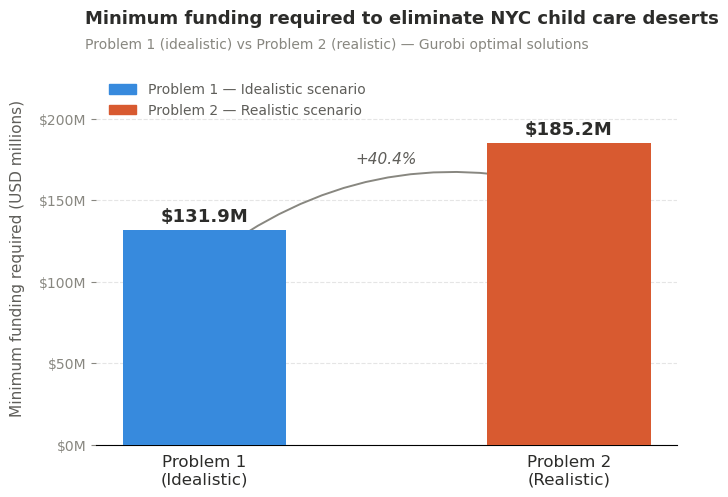

Saved: p1_vs_p2_comparison.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# DATA to create a graph comparing problem 1 to 2
#using the funding valuespreviosuly found

labels   = ['Problem 1\n(Idealistic)', 'Problem 2\n(Realistic)']
values   = [131.9, 185.2]
colors   = ['#378ADD', '#D85A30']
increase = ((185.2 - 131.9) / 131.9) * 100


plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': True,
    'axes.grid':        True,
'axes.grid':        True,
'axes.grid.axis':   'y',
'grid.color':       '#E5E5E5',
'grid.linewidth':   0.8,
'grid.linestyle':   '--',
})

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
x      = np.arange(len(labels))
width  = 0.45
bars   = ax.bar(x, values, width=width, color=colors, zorder=3,
                linewidth=0, clip_on=False)

# Rounded top corners via a second transparent bar overlay trick
for bar, color in zip(bars, colors):
    ax.bar(bar.get_x(), bar.get_height(), width=width,
           color=color, zorder=4, linewidth=0,
           align='edge')


for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2.5,
        f'${val:.1f}M',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold',
        color='#2C2C2A'
    )

ax.annotate(
    '',
    xy=(1, values[1] * 0.85),
    xytext=(0, values[0] * 0.85),
    arrowprops=dict(
        arrowstyle='->', color='#888780',
        lw=1.4,
        connectionstyle='arc3,rad=-0.25'
    )
)
ax.text(
    0.5, (values[0] + values[1]) / 2 + 12,
    f'+{increase:.1f}%',
    ha='center', va='bottom',
    fontsize=11, color='#5F5E5A',
    fontstyle='italic'
)

#creating ticks and labels for axes
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, color='#2C2C2A')
ax.set_ylabel('Minimum funding required (USD millions)',
              fontsize=11, color='#5F5E5A', labelpad=10)
ax.set_ylim(0, 230)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'${v:.0f}M')
)
ax.tick_params(axis='y', colors='#888780', labelsize=10)
ax.tick_params(axis='x', bottom=False)

#adding a legend
patch1 = mpatches.Patch(color='#378ADD', label='Problem 1 — Idealistic scenario')
patch2 = mpatches.Patch(color='#D85A30', label='Problem 2 — Realistic scenario')
ax.legend(
    handles=[patch1, patch2],
    loc='upper left',
    frameon=False,
    fontsize=10,
    labelcolor='#5F5E5A'
)

#creating a title and subtitles

fig.text(
    0.13, 0.96,
    'Minimum funding required to eliminate NYC child care deserts',
    fontsize=13, fontweight='bold', color='#2C2C2A', ha='left'
)
fig.text(
    0.13, 0.91,
    'Problem 1 (idealistic) vs Problem 2 (realistic) — Gurobi optimal solutions',
    fontsize=10, color='#888780', ha='left'
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('p1_vs_p2_comparison.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved: p1_vs_p2_comparison.png")